In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

## Task 1: Implementation of superdense coding.

___
Here is a simple implementation of superdense coding where we specify the circuit itself depending on the bits to be transmitted.

 First we'll choose two bits to be transmitted. (Later we'll choose them randomly, but for now we'll just make an arbitrary choice.)

In [2]:
c = "1"
d = "0"

Now we'll build the circuit accordingly. Here we'll allow Qiskit to use the default names for the qubits: 

* q0 for the top qubit & 
* q1 for the bottom one.

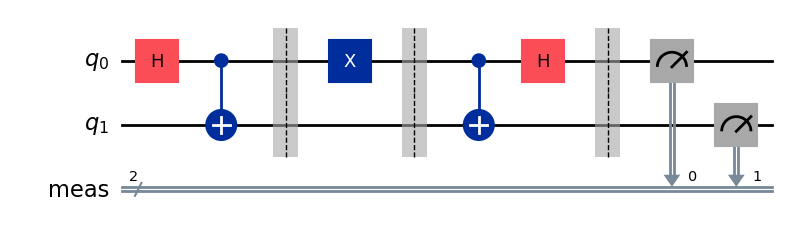

In [3]:
protocol = QuantumCircuit(2)

# Prepare ebit used for superdense coding (ie phi + state)
protocol.h(0)
protocol.cx(0, 1)

protocol.barrier()

# Alice's operations
if d == "1":
    protocol.z(0)
if c == "1":
    protocol.x(0)

protocol.barrier()

# Bob's actions
protocol.cx(0, 1)
protocol.h(0)

protocol.measure_all()

display(protocol.draw(output="mpl"))

Not much is new here, except the measure_all function, which measures all of the qubits and puts the results into a single classical register (and therefore having two bits in this case).

____
Running the Aer simulator produces the expected output.

Measured 10 with frequency 1024


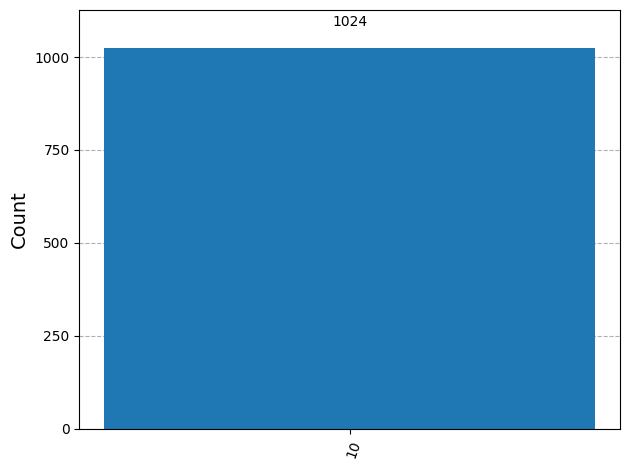

In [4]:
result = AerSimulator().run(protocol).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")

display(plot_histogram(statistics))

## Task 2: Use a random bit generator to generate fairly random classical states

___
Now let's use an additional qubit as a random bit generator — essentially to flip fair coins. 

We'll use it to randomly choose $c$ and $d$, and then run the superdense coding protocol.

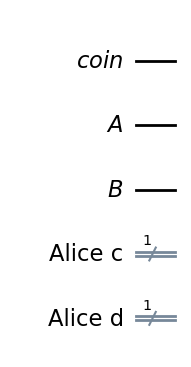

In [6]:
rbg = QuantumRegister(1, "coin")

ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

Alice_c = ClassicalRegister(1, "Alice c")
Alice_d = ClassicalRegister(1, "Alice d")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_c, Alice_d)

display(test.draw(output="mpl"))